# hw4 - NN pyTorch


Во всем задании вы должны работать со входом из строк размером (длиной) 1024


In [179]:
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator, MaxNLocator, MultipleLocator
from scipy import signal
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm


In [180]:
np.random.seed(37)
torch.manual_seed(37)

In [181]:
CONSTS: dict[str, Any] = {
  "sig_length": 1024,
  "N": 500,
  "batch_size": 32,
  "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
  "epochs": 20,
  "N_PSD": 5000,
  "epochs_psd": 25,
}

In [182]:
def GenerateSignal(num_components=5):
  """
  Генерирует синтетический сигнал как суперпозицию синусоид с разными частотами.

  Returns:
      np.ndarray: сгенерированный сигнал
  """

  t = np.linspace(0, 1, CONSTS["sig_length"])
  sum_signal = np.zeros(CONSTS["sig_length"])

  for _ in range(num_components):
    freq = np.random.uniform(1, 50)  # частота от 1 до 50 Гц
    amplitude = np.random.uniform(0.5, 2.0)  # амплитуда от 0.5 до 2.0
    phase = np.random.uniform(0, 2 * np.pi)  # случайная фаза
    sum_signal += amplitude * np.sin(2 * np.pi * freq * t + phase)

  # добавляем небольшой шум
  noise = np.random.normal(0, 0.1, CONSTS["sig_length"])
  sum_signal += noise

  return sum_signal.astype(np.float32)

## Часть 1 Фурье


### Подготовка данных


Сгенерите данные (сигнал) любым пакетом для численного преобразования Фурье, [например](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)


In [183]:
X_train = np.array([GenerateSignal() for _ in range(CONSTS["N"])])
y_train = np.array([np.fft.fft(x) for x in X_train])

y_train_real = y_train.real.astype(np.float32)
y_train_imag = y_train.imag.astype(np.float32)

y_train_combined = np.stack([y_train_real, y_train_imag], axis=1)

print(f"Форма X_train: {X_train.shape}")
print(f"Форма y_train_combined: {y_train_combined.shape}")

print(f"Пример сигнала (первые 10 значений): {X_train[0][:10]}")

Форма X_train: (500, 1024)
Форма y_train_combined: (500, 2, 1024)
Пример сигнала (первые 10 значений): [-0.94815123 -1.1499428  -0.84267944 -0.89809734 -0.7314479  -0.7227919
 -0.420778   -0.07407006  0.2067255   0.8369285 ]


### Соберите и обучите нейросетку на pyTroch для преобразования Фурье


In [184]:
class FFTDataset(Dataset):
  """
  Dataset для обучения нейросети на задачу преобразования Фурье.

  Args:
      X (np.ndarray): Входные сигналы
      y (np.ndarray): Выходные FFT-преобразования (действительная и мнимая части)
  """

  def __init__(self, X, y):
    self.X = torch.FloatTensor(X)
    self.y = torch.FloatTensor(y)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [185]:
class FFTNet(nn.Module):
  """
  Нейронная сеть для аппроксимации быстрого преобразования Фурье (FFT).

  Архитектура состоит из полносвязных слоев с dropout для регуляризации.
  Вход: сигнал длиной 1024
  Выход: 2 x 1024 (действительная и мнимая части FFT)
  """

  def __init__(self):
    super().__init__()

    input_size = CONSTS["sig_length"]
    output_size = CONSTS["sig_length"]

    self.network = nn.Sequential(
      nn.Linear(input_size, 2048),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(2048, 4096),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(4096, 4096),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(4096, 2048),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(2048, 2 * output_size),
    )

  def Forward(self, x):
    """
    Прямой проход через сеть.

    Args:
        x (torch.Tensor): Входной тензор формы (batch_size, input_size)

    Returns:
        torch.Tensor: Выходной тензор формы (batch_size, 2, output_size)
    """

    out = self.network(x)
    # преобразуем выход в формат (batch_size, 2, output_size)
    out = out.view(-1, 2, CONSTS["sig_length"])

    return out

  def forward(self, x):
    return self.Forward(x)


def Train(
  model: nn.Module,
  train_loader: DataLoader,
  criterion,
  optimizer,
  num_epochs: int,
):
  """
  Обучает модель на заданном наборе данных.

  Args:
      model (nn.Module): Модель для обучения
      train_loader (DataLoader): Загрузчик обучающих данных
      criterion: Функция потерь
      optimizer: Оптимизатор
      num_epochs (int): Количество эпох обучения

  Returns:
      list: История потерь на каждой эпохе
  """

  model.train()
  loss_history = []

  for epoch in range(num_epochs):
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Эпоха {epoch + 1}/{num_epochs}")

    for inputs, targets in progress_bar:
      inputs = inputs.to(CONSTS["device"])
      targets = targets.to(CONSTS["device"])

      optimizer.zero_grad()  # обнуляем градиенты
      outputs = model(inputs)  # прямой проход
      loss = criterion(outputs, targets)  # вычисляем функцию потерь
      loss.backward()  # обратное распространение
      optimizer.step()

      epoch_loss += loss.item()
      progress_bar.set_postfix({"loss": loss.item()})

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Эпоха [{epoch + 1}/{num_epochs}], Средняя потеря: {avg_loss:.6f}")

  return loss_history

In [186]:
train_dataset = FFTDataset(X_train, y_train_combined)
train_loader = DataLoader(train_dataset, batch_size=CONSTS["batch_size"], shuffle=True)

model = FFTNet().to(CONSTS["device"])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("\nМодель FFTNet:")
print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")
print("\nНачинаем обучение...")



Модель FFTNet:
Количество параметров: 39,860,224

Начинаем обучение...


In [187]:
loss_history = Train(model, train_loader, criterion, optimizer, CONSTS["epochs"])

Эпоха 1/20: 100%|██████████| 16/16 [00:05<00:00,  2.83it/s, loss=2.43e+3]


Эпоха [1/20], Средняя потеря: 2231.510429


Эпоха 2/20: 100%|██████████| 16/16 [00:05<00:00,  3.16it/s, loss=2.06e+3]


Эпоха [2/20], Средняя потеря: 2203.013245


Эпоха 3/20: 100%|██████████| 16/16 [00:05<00:00,  2.90it/s, loss=2e+3]   


...

Эпоха [18/20], Средняя потеря: 1175.056778


Эпоха 19/20: 100%|██████████| 16/16 [00:05<00:00,  3.10it/s, loss=1.12e+3]


Эпоха [19/20], Средняя потеря: 1114.960949


Эпоха 20/20: 100%|██████████| 16/16 [00:05<00:00,  2.98it/s, loss=1.01e+3]

Эпоха [20/20], Средняя потеря: 1045.531704


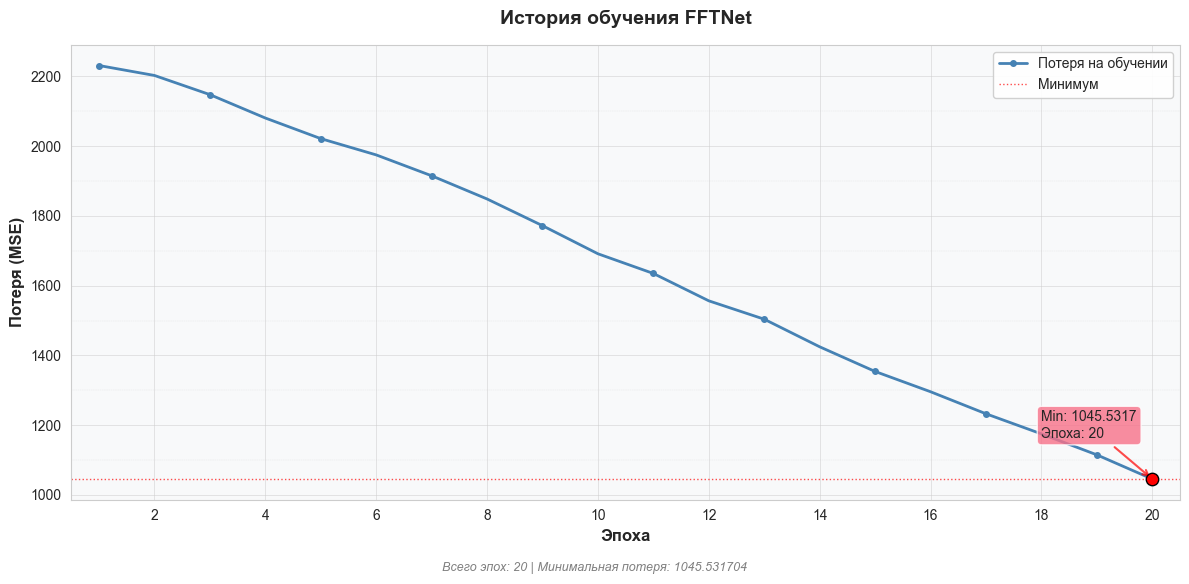

In [188]:
plt.figure(figsize=(12, 6))

# основной график
plt.plot(
  range(1, len(loss_history) + 1),
  loss_history,
  label="Потеря на обучении",
  color="steelblue",
  linewidth=2,
  marker="o",
  markersize=4,
  markevery=max(1, len(loss_history) // 10),
)

plt.xlabel("Эпоха", fontsize=12, fontweight="bold")
plt.ylabel("Потеря (MSE)", fontsize=12, fontweight="bold")
plt.title("История обучения FFTNet", fontsize=14, fontweight="bold", pad=15)

ax = plt.gca()

ax.set_xlim(0.5, len(loss_history) + 0.5)

ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=min(10, len(loss_history))))
ax.xaxis.set_minor_locator(MultipleLocator(1))

if loss_history:
  y_min, y_max = min(loss_history), max(loss_history)
  y_padding = (y_max - y_min) * 0.05 if y_max > y_min else 0.1
  ax.set_ylim(y_min - y_padding, y_max + y_padding)

  y_range = y_max - y_min
  if y_range > 0:
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
  else:
    # если все значения примерно одинаковы
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.02))

ax.grid(which="major", linestyle="-", linewidth=0.5, alpha=0.7)
ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.3, alpha=0.5)

# добавление аннотации с минимальным значением потерь
if loss_history and len(loss_history) > 1:
  min_loss = min(loss_history)
  min_epoch = loss_history.index(min_loss) + 1

  annotation_x = min(min_epoch + len(loss_history) * 0.05, len(loss_history) * 0.9)
  annotation_y = min(
    min_loss + (max(loss_history) - min(loss_history)) * 0.1, max(loss_history) * 0.9
  )

  plt.axhline(
    y=min_loss, color="r", linestyle=":", linewidth=1, alpha=0.7, label="Минимум"
  )
  plt.scatter(min_epoch, min_loss, color="red", s=80, zorder=5, edgecolors="black")

  plt.annotate(
    f"Min: {min_loss:.4f}\nЭпоха: {min_epoch}",
    xy=(min_epoch, min_loss),
    xytext=(annotation_x, annotation_y),
    arrowprops=dict(arrowstyle="->", color="red", alpha=0.7, lw=1.5),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", alpha=0.8),
  )

plt.legend(loc="upper right", fontsize=10, framealpha=0.9)

ax.set_facecolor("#f8f9fa")

if loss_history:
  plt.figtext(
    0.5,
    0.01,
    f"Всего эпох: {len(loss_history)} | Минимальная потеря: {min(loss_history):.6f}",
    ha="center",
    fontsize=9,
    style="italic",
    color="gray",
  )

plt.tight_layout(rect=[0, 0.03, 1, 0.97])  # type: ignore
plt.show()


In [189]:
if loss_history:
  print("\n" + "=" * 50)
  print("СТАТИСТИКА ОБУЧЕНИЯ")
  print("=" * 50)
  print(f"{'Параметр':<25} {'Значение':>20}")
  print("-" * 50)
  print(f"{'Начальная потеря:':<25} {loss_history[0]:>20.6f}")
  print(f"{'Финальная потеря:':<25} {loss_history[-1]:>20.6f}")
  print(f"{'Минимальная потеря:':<25} {min(loss_history):>20.6f}")
  print(f"{'Эпоха минимума:':<25} {loss_history.index(min(loss_history)) + 1:>20}")

  if loss_history[0] > 0:
    improvement = ((loss_history[0] - loss_history[-1]) / loss_history[0]) * 100
    print(f"{'Улучшение (%):':<25} {improvement:>20.1f}")

  avg_loss = sum(loss_history) / len(loss_history)
  print(f"{'Средняя потеря:':<25} {avg_loss:>20.6f}")
  print("=" * 50)


СТАТИСТИКА ОБУЧЕНИЯ
Параметр                              Значение
--------------------------------------------------
Начальная потеря:                  2231.510429
Финальная потеря:                  1045.531704
Минимальная потеря:                1045.531704
Эпоха минимума:                             20
Улучшение (%):                            53.1
Средняя потеря:                    1661.357942


### Сравните свое решение с пакетным методом


In [190]:
# тестовые сигналы
n_test = 5
test_signals = np.array([GenerateSignal() for _ in range(n_test)])

# предсказания от нейросети
model.eval()
with torch.no_grad():
  test_tensor = torch.FloatTensor(test_signals).to(CONSTS["device"])
  predictions = model(test_tensor).cpu().numpy()

# вычисляем FFT пакетным методом
fft_numpy = np.array([np.fft.fft(sig) for sig in test_signals])


C:\Users\dmitr\AppData\Local\Temp\ipykernel_10860\3332494375.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


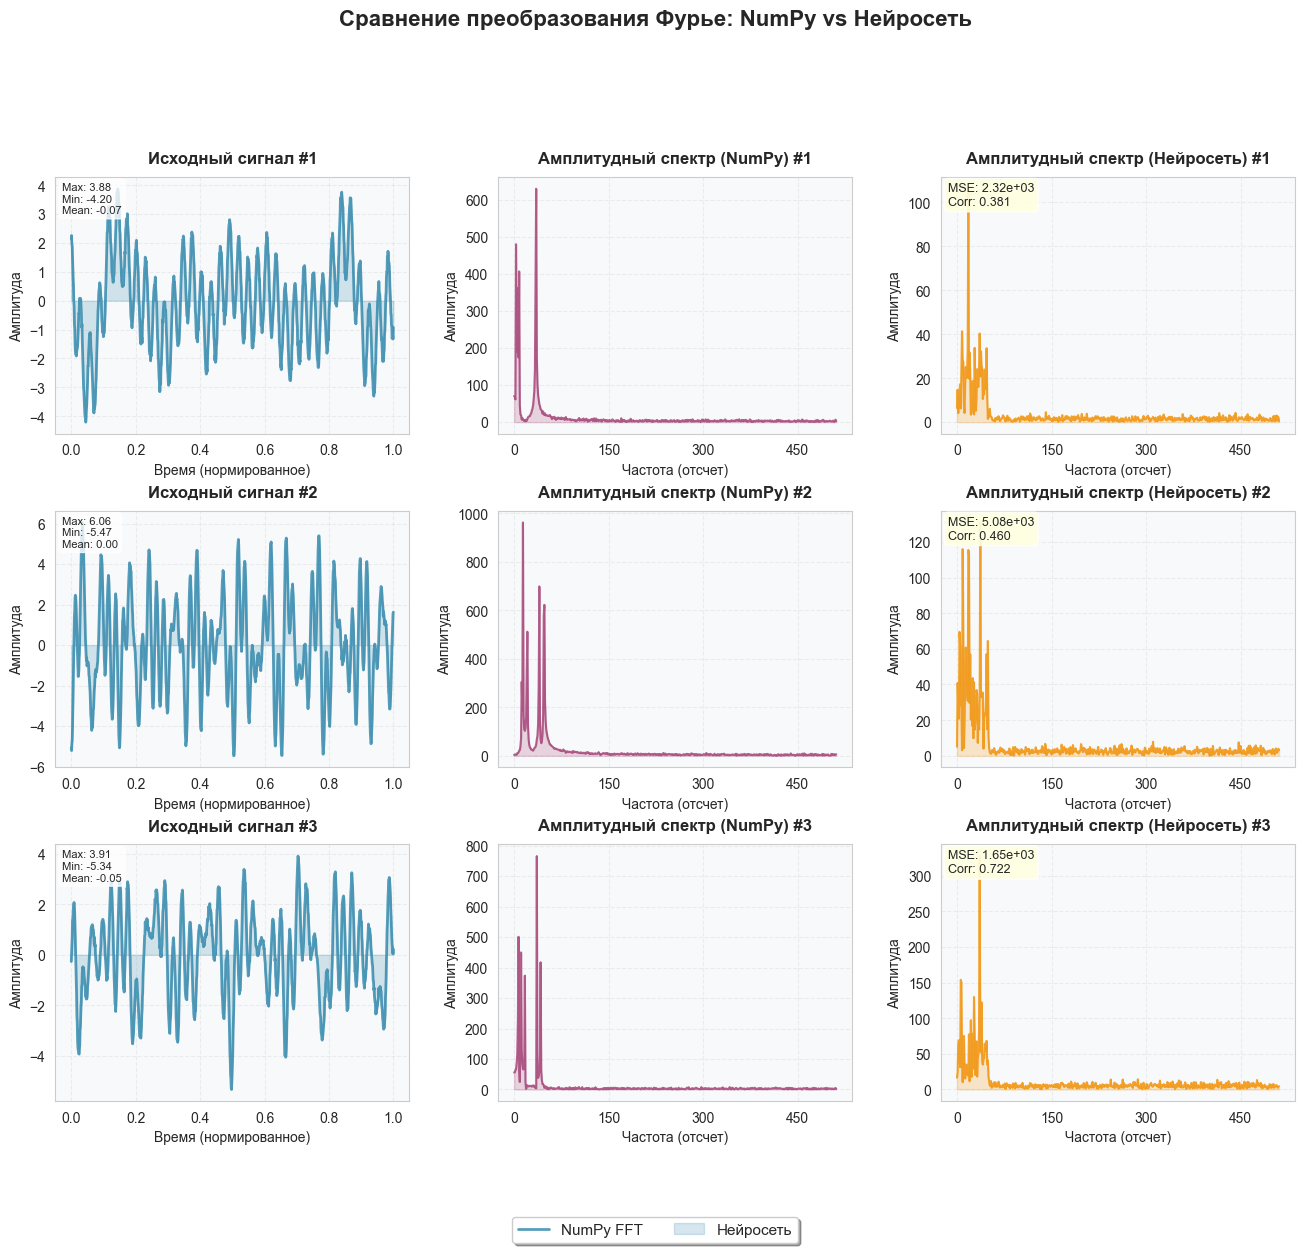

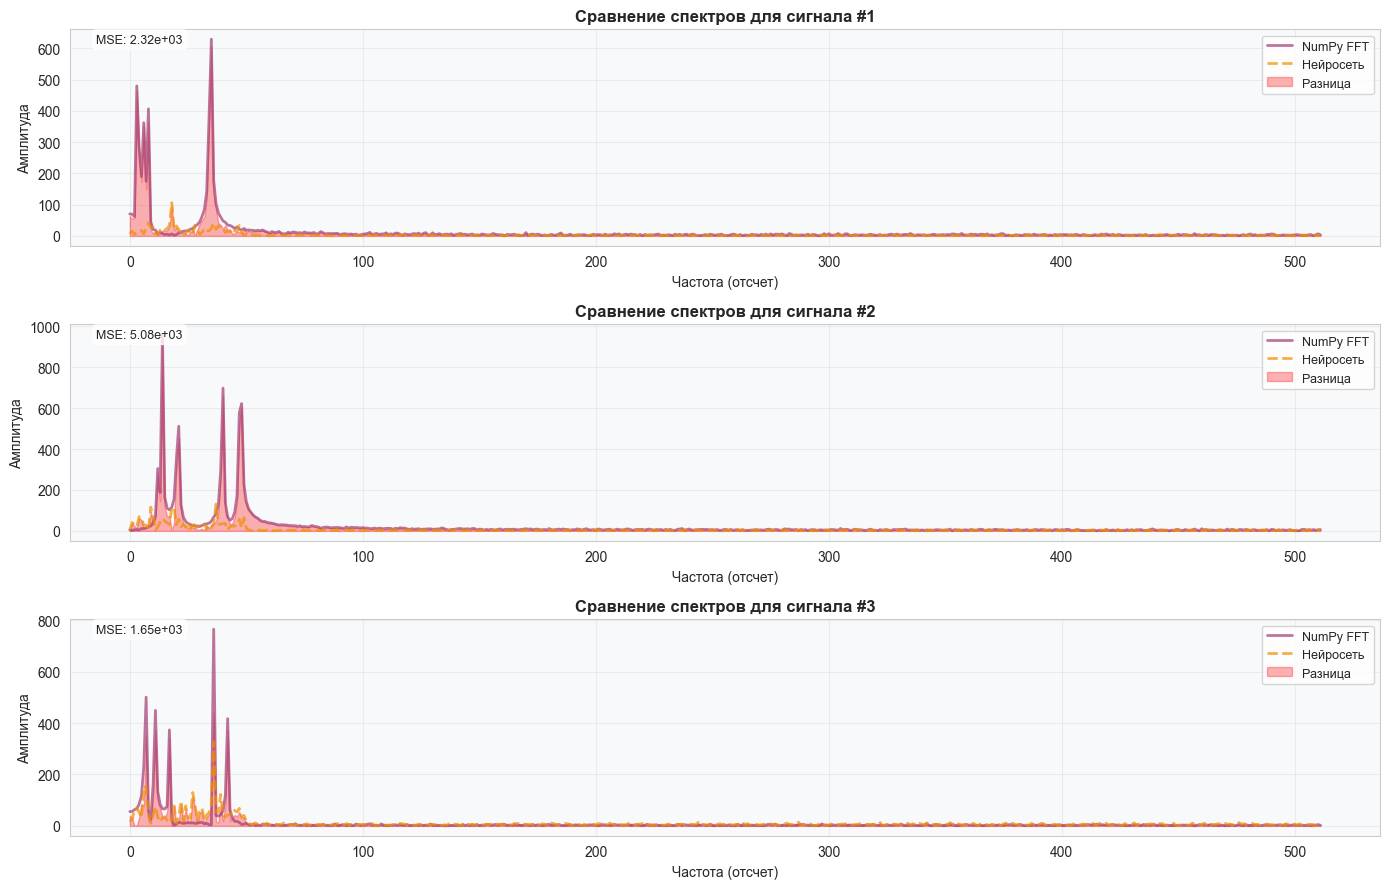

In [191]:
n_test = min(3, len(test_signals))

fig = plt.figure(figsize=(16, 4 * n_test))
fig.suptitle(
  "Сравнение преобразования Фурье: NumPy vs Нейросеть",
  fontsize=16,
  fontweight="bold",
  y=1.02,
)

gs = GridSpec(n_test, 3, figure=fig, hspace=0.3, wspace=0.25)

for i in range(n_test):
  fft_magnitude_numpy = np.abs(fft_numpy[i])
  fft_nn = predictions[i][0] + 1j * predictions[i][1]
  fft_magnitude_nn = np.abs(fft_nn)

  half_len = CONSTS["sig_length"] // 2
  freqs = np.arange(half_len)

  # 1. Исходный сигнал
  ax0 = fig.add_subplot(gs[i, 0])
  time = np.linspace(0, 1, CONSTS["sig_length"])
  ax0.plot(time, test_signals[i], color="#2E86AB", linewidth=2, alpha=0.8)
  ax0.fill_between(time, test_signals[i], alpha=0.2, color="#2E86AB")
  ax0.set_title(f"Исходный сигнал #{i + 1}", fontsize=12, fontweight="bold", pad=10)
  ax0.set_xlabel("Время (нормированное)", fontsize=10)
  ax0.set_ylabel("Амплитуда", fontsize=10)
  ax0.grid(True, alpha=0.3, linestyle="--")
  ax0.set_facecolor("#f8f9fa")

  stats_text = f"Max: {test_signals[i].max():.2f}\nMin: {test_signals[i].min():.2f}\nMean: {test_signals[i].mean():.2f}"
  ax0.text(
    0.02,
    0.98,
    stats_text,
    transform=ax0.transAxes,
    fontsize=8,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
  )

  # 2. FFT от numpy
  ax1 = fig.add_subplot(gs[i, 1])
  ax1.plot(
    freqs,
    fft_magnitude_numpy[:half_len],
    color="#A23B72",
    linewidth=1.5,
    alpha=0.8,
    label="NumPy FFT",
  )
  ax1.fill_between(freqs, fft_magnitude_numpy[:half_len], alpha=0.2, color="#A23B72")
  ax1.set_title(
    f"Амплитудный спектр (NumPy) #{i + 1}", fontsize=12, fontweight="bold", pad=10
  )
  ax1.set_xlabel("Частота (отсчет)", fontsize=10)
  ax1.set_ylabel("Амплитуда", fontsize=10)
  ax1.grid(True, alpha=0.3, linestyle="--")
  ax1.set_facecolor("#f8f9fa")
  ax1.xaxis.set_major_locator(MaxNLocator(5))

  # 3. FFT от нейросети
  ax2 = fig.add_subplot(gs[i, 2])
  ax2.plot(
    freqs,
    fft_magnitude_nn[:half_len],
    color="#F18F01",
    linewidth=1.5,
    alpha=0.8,
    label="Нейросеть",
  )
  ax2.fill_between(freqs, fft_magnitude_nn[:half_len], alpha=0.2, color="#F18F01")
  ax2.set_title(
    f"Амплитудный спектр (Нейросеть) #{i + 1}", fontsize=12, fontweight="bold", pad=10
  )
  ax2.set_xlabel("Частота (отсчет)", fontsize=10)
  ax2.set_ylabel("Амплитуда", fontsize=10)
  ax2.grid(True, alpha=0.3, linestyle="--")
  ax2.set_facecolor("#f8f9fa")
  ax2.xaxis.set_major_locator(MaxNLocator(5))

  mse = np.mean((fft_magnitude_numpy[:half_len] - fft_magnitude_nn[:half_len]) ** 2)
  correlation = np.corrcoef(fft_magnitude_numpy[:half_len], fft_magnitude_nn[:half_len])[
    0, 1
  ]

  comparison_text = f"MSE: {mse:.2e}\nCorr: {correlation:.3f}"
  ax2.text(
    0.02,
    0.98,
    comparison_text,
    transform=ax2.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9),
  )

fig.legend(
  ["NumPy FFT", "Нейросеть"],
  loc="upper center",
  bbox_to_anchor=(0.5, 0.02),
  ncol=2,
  fontsize=11,
  frameon=True,
  fancybox=True,
  shadow=True,
)

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(n_test, 1, figsize=(14, 3 * n_test))
if n_test == 1:
  axes2 = [axes2]

for i in range(n_test):
  fft_magnitude_numpy = np.abs(fft_numpy[i])
  fft_nn = predictions[i][0] + 1j * predictions[i][1]
  fft_magnitude_nn = np.abs(fft_nn)
  half_len = CONSTS["sig_length"] // 2
  freqs = np.arange(half_len)

  axes2[i].plot(
    freqs,
    fft_magnitude_numpy[:half_len],
    color="#A23B72",
    linewidth=2,
    label="NumPy FFT",
    alpha=0.7,
  )
  axes2[i].plot(
    freqs,
    fft_magnitude_nn[:half_len],
    color="#F18F01",
    linewidth=2,
    label="Нейросеть",
    alpha=0.7,
    linestyle="--",
  )

  diff = np.abs(fft_magnitude_numpy[:half_len] - fft_magnitude_nn[:half_len])
  axes2[i].fill_between(freqs, 0, diff, alpha=0.3, color="red", label="Разница")

  axes2[i].set_title(
    f"Сравнение спектров для сигнала #{i + 1}", fontsize=12, fontweight="bold"
  )
  axes2[i].set_xlabel("Частота (отсчет)", fontsize=10)
  axes2[i].set_ylabel("Амплитуда", fontsize=10)
  axes2[i].legend(loc="upper right", fontsize=9)
  axes2[i].grid(True, alpha=0.3)
  axes2[i].set_facecolor("#f8f9fa")

  mse = np.mean(diff**2)
  axes2[i].text(
    0.02,
    0.98,
    f"MSE: {mse:.2e}",
    transform=axes2[i].transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
  )

plt.tight_layout()
plt.show()


In [192]:
# вычисляем метрики качества
print("\nСравнение FFT: NumPy vs Нейросеть\n")
for i in range(n_test):
  fft_nn = predictions[i][0] + 1j * predictions[i][1]

  # MSE между действительными частями
  mse_real = np.mean((fft_numpy[i].real - predictions[i][0]) ** 2)
  # MSE между мнимыми частями
  mse_imag = np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2)
  # MSE для амплитудных спектров
  mse_magnitude = np.mean((np.abs(fft_numpy[i]) - np.abs(fft_nn)) ** 2)

  # корреляция между амплитудными спектрами
  correlation = np.corrcoef(np.abs(fft_numpy[i]), np.abs(fft_nn))[0, 1]

  print(f"Тестовый сигнал #{i + 1}:")
  print(f"  MSE (действительная часть): {mse_real:.4f}")
  print(f"  MSE (мнимая часть): {mse_imag:.4f}")
  print(f"  MSE (амплитудный спектр): {mse_magnitude:.4f}")
  print(f"  Корреляция (амплитудный спектр): {correlation:.6f}")
  print()

# среднее по всем тестовым сигналам
avg_mse_real = np.mean(
  [np.mean((fft_numpy[i].real - predictions[i][0]) ** 2) for i in range(n_test)]
)
avg_mse_imag = np.mean(
  [np.mean((fft_numpy[i].imag - predictions[i][1]) ** 2) for i in range(n_test)]
)
avg_correlation = np.mean(
  [
    np.corrcoef(np.abs(fft_numpy[i]), np.abs(predictions[i][0] + 1j * predictions[i][1]))[
      0, 1
    ]
    for i in range(n_test)
  ]
)

print("Средние метрики:")
print(f"  Средний MSE (действительная часть): {avg_mse_real:.4f}")
print(f"  Средний MSE (мнимая часть): {avg_mse_imag:.4f}")
print(f"  Средняя корреляция (амплитудный спектр): {avg_correlation:.6f}")


Сравнение FFT: NumPy vs Нейросеть

Тестовый сигнал #1:
  MSE (действительная часть): 1304.0936
  MSE (мнимая часть): 1183.9417
  MSE (амплитудный спектр): 2314.5386
  Корреляция (амплитудный спектр): 0.378144

Тестовый сигнал #2:
  MSE (действительная часть): 2923.8765
  MSE (мнимая часть): 2756.8184
  MSE (амплитудный спектр): 5070.0498
  Корреляция (амплитудный спектр): 0.463093

Тестовый сигнал #3:
  MSE (действительная часть): 1361.4023
  MSE (мнимая часть): 637.6600
  MSE (амплитудный спектр): 1655.5917
  Корреляция (амплитудный спектр): 0.722688

Средние метрики:
  Средний MSE (действительная часть): 1863.1241
  Средний MSE (мнимая часть): 1526.1400
  Средняя корреляция (амплитудный спектр): 0.521308


## Часть 2 Power spectral density (dB)


### Подготовка данных


Используя пакетное решение, [например](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html), подготовьте обучающую выборку.


In [193]:
# генерация обучающей выборки для PSD
print("Генерация обучающей выборки для PSD...")

X_train_psd = np.array([GenerateSignal() for _ in range(CONSTS["N_PSD"])])

# periodogram возвращает частоты и плотности мощности
y_train_psd = []

for sig in X_train_psd:
  freqs, psd = signal.periodogram(sig, fs=1.0, scaling="density")
  # преобразуем в dB
  psd_db = 10 * np.log10(psd + 1e-10)  # добавляем малое значение для избежания log(0)
  y_train_psd.append(psd_db)

y_train_psd = np.array(y_train_psd, dtype=np.float32)

print(f"Форма X_train_psd: {X_train_psd.shape}")
print(f"Форма y_train_psd: {y_train_psd.shape}")
print(f"Длина входа: {X_train_psd.shape[1]}")
print(f"Длина выхода: {y_train_psd.shape[1]}")


Генерация обучающей выборки для PSD...
Форма X_train_psd: (5000, 1024)
Форма y_train_psd: (5000, 513)
Длина входа: 1024
Длина выхода: 513


C:\Users\dmitr\AppData\Local\Temp\ipykernel_10860\3368053419.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


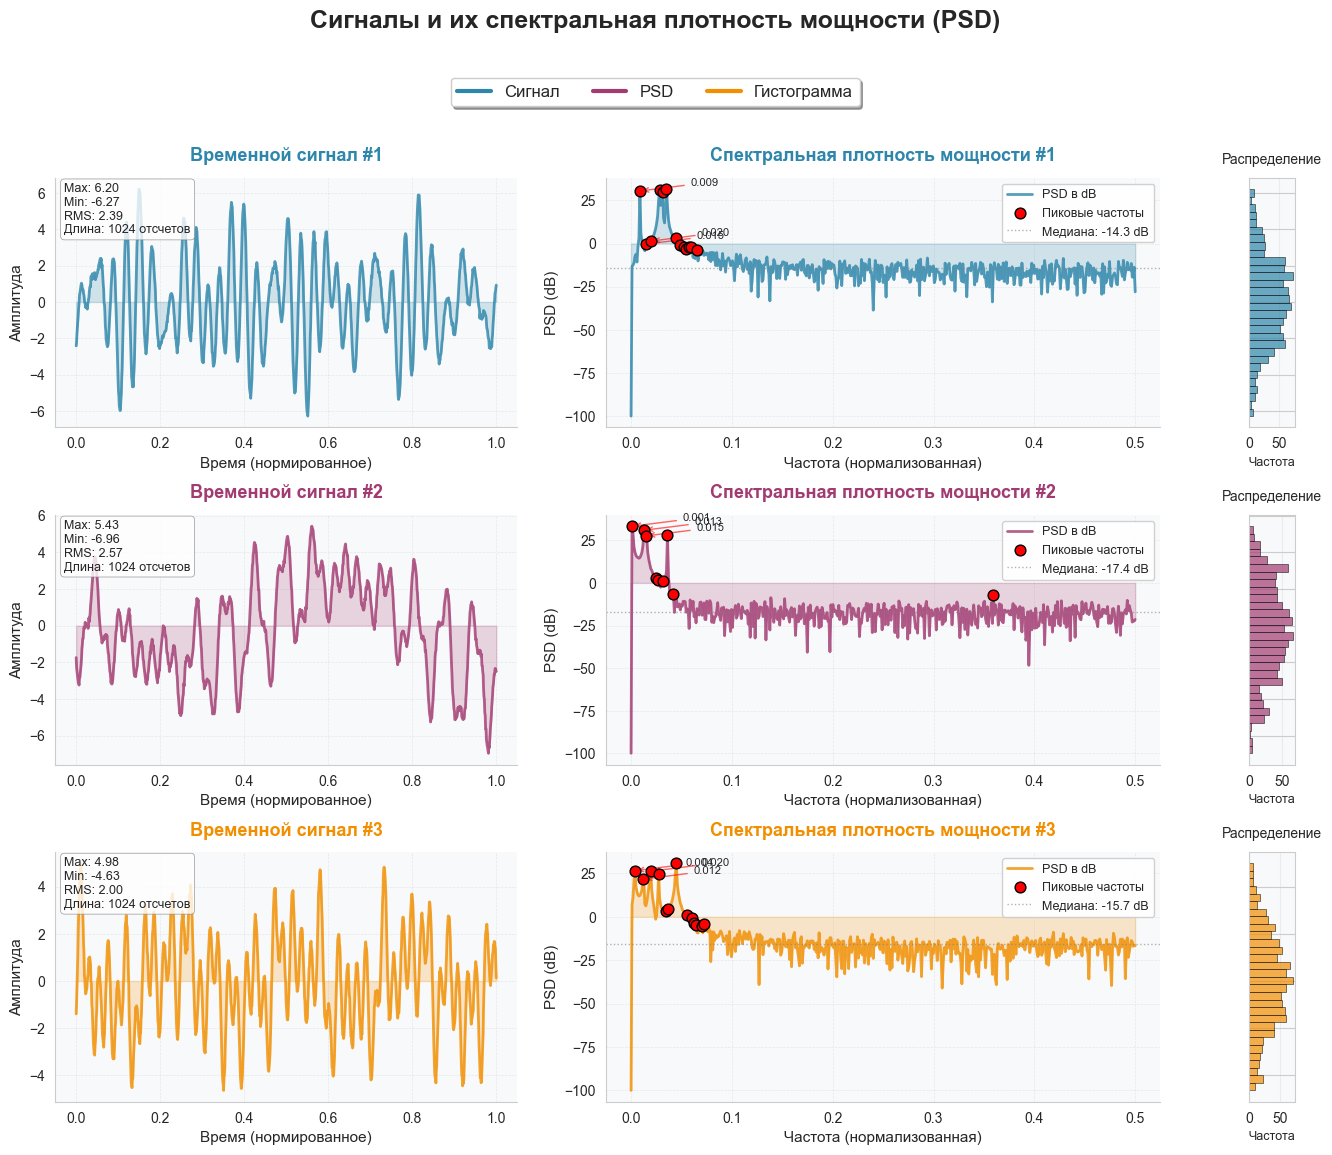

In [ ]:
# визуализация примеров
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
  "Сигналы и их спектральная плотность мощности (PSD)",
  fontsize=18,
  fontweight="bold",
  y=1.02,
)

# используем GridSpec для лучшего контроля
gs = GridSpec(
  3,
  3,
  figure=fig,
  hspace=0.35,
  wspace=0.25,
  height_ratios=[1, 1, 1],
  width_ratios=[1, 1.2, 0.1],
)

# Цветовая палитра для разных сигналов
colors = ["#2E86AB", "#A23B72", "#F18F01"]
color_names = ["Синий", "Пурпурный", "Оранжевый"]

for i in range(3):
  # 1. Исходный сигнал
  ax_sig = fig.add_subplot(gs[i, 0])
  time = np.linspace(0, 1, CONSTS["sig_length"])

  ax_sig.plot(
    time,
    X_train_psd[i],
    color=colors[i],
    linewidth=2,
    alpha=0.8,
    label=f"Сигнал #{i + 1}",
  )

  ax_sig.fill_between(time, X_train_psd[i], alpha=0.2, color=colors[i])

  ax_sig.set_title(
    f"Временной сигнал #{i + 1}", fontsize=13, fontweight="bold", color=colors[i], pad=12
  )

  ax_sig.set_xlabel("Время (нормированное)", fontsize=11)
  ax_sig.set_ylabel("Амплитуда", fontsize=11)
  ax_sig.grid(True, alpha=0.4, linestyle="--", linewidth=0.5)
  ax_sig.set_facecolor("#f8f9fa")

  ax_sig.spines["top"].set_visible(False)
  ax_sig.spines["right"].set_visible(False)

  ax_sig.xaxis.set_major_locator(MaxNLocator(6))

  sig_stats = X_train_psd[i]
  stats_text = (
    f"Max: {sig_stats.max():.2f}\n"
    f"Min: {sig_stats.min():.2f}\n"
    f"RMS: {np.sqrt(np.mean(sig_stats**2)):.2f}\n"
    f"Длина: {len(sig_stats)} отсчетов"
  )

  ax_sig.text(
    0.02,
    0.98,
    stats_text,
    transform=ax_sig.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(
      boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray", linewidth=0.5
    ),
  )

  # 2. PSD в dB
  ax_psd = fig.add_subplot(gs[i, 1])

  freqs, psd_raw = signal.periodogram(X_train_psd[i], fs=1.0, scaling="density")

  ax_psd.plot(
    freqs, y_train_psd[i], color=colors[i], linewidth=2, alpha=0.8, label="PSD в dB"
  )

  ax_psd.fill_between(freqs, y_train_psd[i], alpha=0.2, color=colors[i])

  # отмечаем пиковые частоты
  peak_indices = signal.find_peaks(y_train_psd[i], height=np.median(y_train_psd[i]) + 10)[
    0
  ]
  if len(peak_indices) > 0:
    peak_freqs = freqs[peak_indices]
    peak_values = y_train_psd[i][peak_indices]

    ax_psd.scatter(
      peak_freqs,
      peak_values,
      color="red",
      s=60,
      zorder=5,
      edgecolors="black",
      linewidth=1,
      label="Пиковые частоты",
    )

    # аннотации для пиков
    for freq, val in zip(peak_freqs[:3], peak_values[:3], strict=False):
      ax_psd.annotate(
        f"{freq:.3f}",
        xy=(freq, val),
        xytext=(freq + 0.05, val + 3),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="red", alpha=0.6, linewidth=1),
      )

  ax_psd.set_title(
    f"Спектральная плотность мощности #{i + 1}",
    fontsize=13,
    fontweight="bold",
    color=colors[i],
    pad=12,
  )

  ax_psd.set_xlabel("Частота (нормализованная)", fontsize=11)
  ax_psd.set_ylabel("PSD (dB)", fontsize=11)
  ax_psd.grid(True, alpha=0.4, linestyle="--", linewidth=0.5)
  ax_psd.set_facecolor("#f8f9fa")

  ax_psd.spines["top"].set_visible(False)
  ax_psd.spines["right"].set_visible(False)

  ax_psd.xaxis.set_major_locator(MaxNLocator(6))
  ax_psd.yaxis.set_major_locator(MaxNLocator(6))

  median_psd = np.median(y_train_psd[i])
  ax_psd.axhline(
    y=median_psd,
    color="gray",
    linestyle=":",
    linewidth=1,
    alpha=0.6,
    label=f"Медиана: {median_psd:.1f} dB",
  )

  ax_psd.legend(loc="upper right", fontsize=9, framealpha=0.9)

  # 3. Гистограмма сигнала (боковая панель)
  ax_hist = fig.add_subplot(gs[i, 2])

  n_bins = min(30, len(X_train_psd[i]) // 10)
  ax_hist.hist(
    X_train_psd[i],
    bins=n_bins,
    orientation="horizontal",
    color=colors[i],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
  )

  ax_hist.set_title("Распределение", fontsize=10, pad=10)
  ax_hist.set_xlabel("Частота", fontsize=9)
  ax_hist.set_ylabel("")
  ax_hist.yaxis.set_ticklabels([])
  ax_hist.grid(True, alpha=0.3, axis="x")
  ax_hist.set_facecolor("#f8f9fa")

# Общая легенда для типов графиков
handles = [
  plt.Line2D([0], [0], color="#2E86AB", lw=3, label="Сигнал"),
  plt.Line2D([0], [0], color="#A23B72", lw=3, label="PSD"),
  plt.Line2D([0], [0], color="#F18F01", lw=3, label="Гистограмма"),
]

fig.legend(
  handles=handles,
  loc="upper center",
  bbox_to_anchor=(0.5, 0.97),
  ncol=3,
  fontsize=12,
  frameon=True,
  fancybox=True,
  shadow=True,
  borderaxespad=0.5,
)

plt.tight_layout()
plt.show()

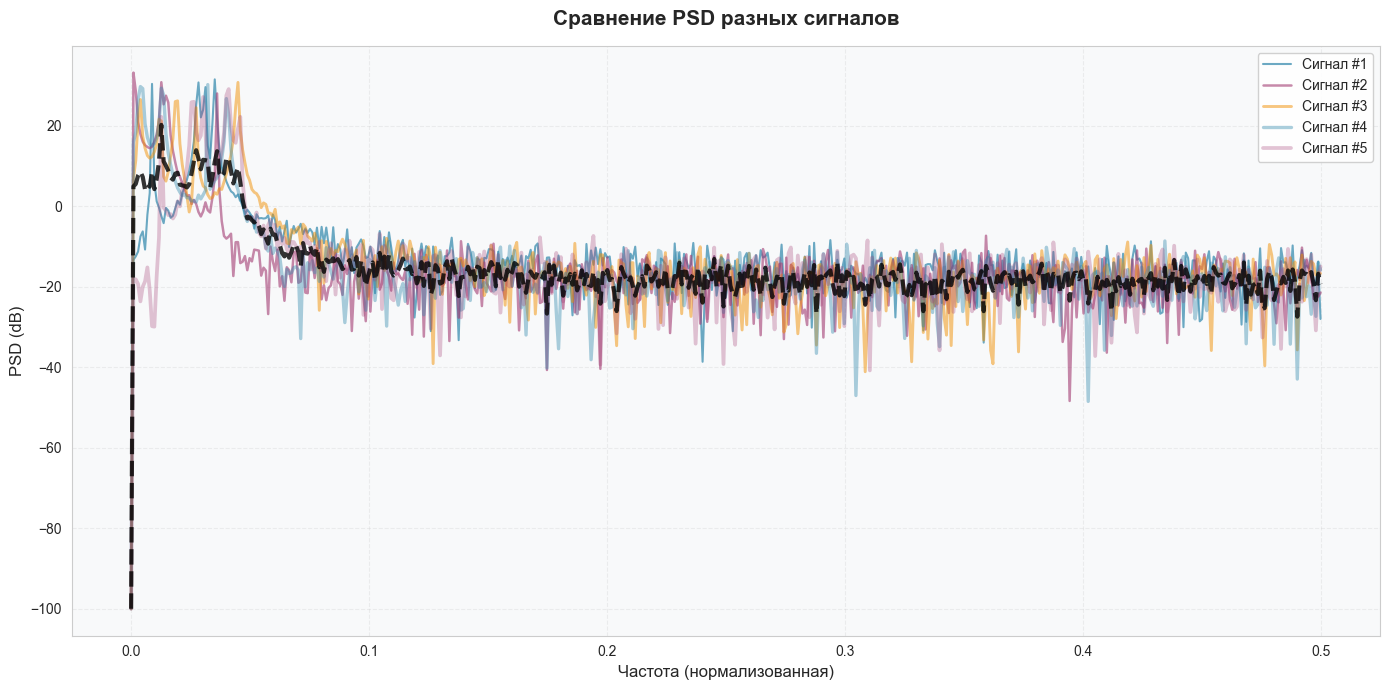

In [195]:
fig2, ax2 = plt.subplots(figsize=(14, 7))

for i in range(min(5, len(X_train_psd))):
  freqs, _ = signal.periodogram(X_train_psd[i], fs=1.0, scaling="density")

  alpha_val = 0.7 - (i * 0.1)

  ax2.plot(
    freqs,
    y_train_psd[i],
    color=colors[i % len(colors)],
    linewidth=1.5 + (i * 0.3),
    alpha=alpha_val,
    label=f"Сигнал #{i + 1}",
  )

ax2.set_title("Сравнение PSD разных сигналов", fontsize=15, fontweight="bold", pad=15)
ax2.set_xlabel("Частота (нормализованная)", fontsize=12)
ax2.set_ylabel("PSD (dB)", fontsize=12)
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.set_facecolor("#f8f9fa")
ax2.legend(loc="upper right", fontsize=10, framealpha=0.9)

if len(X_train_psd) > 1:
  mean_psd_all = np.mean(y_train_psd[: min(5, len(X_train_psd))], axis=0)
  ax2.plot(
    freqs,
    mean_psd_all,
    color="black",
    linewidth=3,
    linestyle="--",
    alpha=0.8,
    label="Средняя PSD",
  )

plt.tight_layout()
plt.show()

### Соберите и обучите нейросеть для предсказания спектральной плотности мощности


_Подсказка: для входа 1024 выход будет 512_


In [196]:
class PSDDataset(Dataset):
  """
  Dataset для обучения нейросети на задачу предсказания спектральной плотности мощности.

  Args:
      X (np.ndarray): Входные сигналы
      y (np.ndarray): Выходные PSD в dB
  """

  def __init__(self, X, y):
    self.X = torch.FloatTensor(X)
    self.y = torch.FloatTensor(y)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


class PSDNet(nn.Module):
  """
  Нейронная сеть для предсказания спектральной плотности мощности (PSD).

  Архитектура состоит из полносвязных слоев с dropout для регуляризации.
  Вход: сигнал длиной 1024
  Выход: PSD длиной 513 (в dB)
  """

  def __init__(self, input_size=1024, output_size=513):
    super().__init__()

    self.network = nn.Sequential(
      nn.Linear(input_size, 2048),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(2048, 2048),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(2048, 1024),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(1024, 512),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(512, output_size),
    )

  def forward(self, x):
    """
    Прямой проход через сеть.

    Args:
        x (torch.Tensor): Входной тензор формы (batch_size, input_size)

    Returns:
        torch.Tensor: Выходной тензор формы (batch_size, output_size)
    """
    return self.network(x)


In [197]:
# создаем Dataset и DataLoader для PSD
psd_dataset = PSDDataset(X_train_psd, y_train_psd)
psd_loader = DataLoader(psd_dataset, batch_size=CONSTS["batch_size"], shuffle=True)

# инициализируем модель, функцию потерь и оптимизатор
psd_model = PSDNet().to(CONSTS["device"])
psd_criterion = nn.MSELoss()
psd_optimizer = optim.Adam(psd_model.parameters(), lr=0.001)

print("Модель PSDNet:")
print(f"Количество параметров: {sum(p.numel() for p in psd_model.parameters()):,}")
print("\nНачинаем обучение PSD модели...")


Модель PSDNet:
Количество параметров: 9,181,697

Начинаем обучение PSD модели...


In [198]:
psd_loss_history = Train(
  psd_model,
  psd_loader,
  psd_criterion,
  psd_optimizer,
  CONSTS["epochs_psd"],
)

Эпоха 1/25: 100%|██████████| 157/157 [00:11<00:00, 13.23it/s, loss=59.5]


Эпоха [1/25], Средняя потеря: 79.619197


Эпоха 2/25: 100%|██████████| 157/157 [00:11<00:00, 13.89it/s, loss=57.8]


Эпоха [2/25], Средняя потеря: 59.187340


Эпоха 3/25: 100%|██████████| 157/157 [00:11<00:00, 13.26it/s, loss=52.5]


...

Эпоха [23/25], Средняя потеря: 40.062871


Эпоха 24/25: 100%|██████████| 157/157 [00:12<00:00, 12.16it/s, loss=41.8]


Эпоха [24/25], Средняя потеря: 39.740530


Эпоха 25/25: 100%|██████████| 157/157 [00:13<00:00, 11.91it/s, loss=43.5]

Эпоха [25/25], Средняя потеря: 39.329813


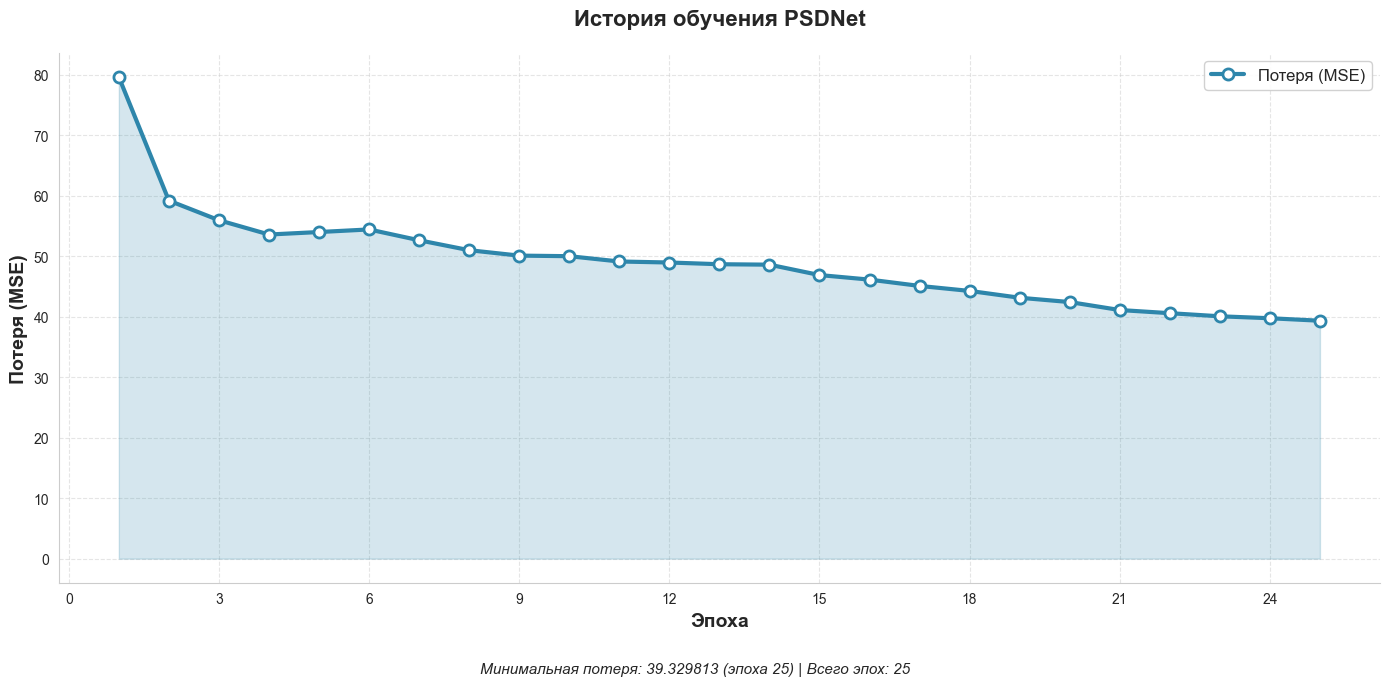

In [200]:
plt.figure(figsize=(14, 7))

epochs = range(1, len(psd_loss_history) + 1)

# основной график потерь
plt.plot(
  epochs,
  psd_loss_history,
  color="#2E86AB",
  linewidth=3,
  marker="o",
  markersize=8,
  markerfacecolor="white",
  markeredgecolor="#2E86AB",
  markeredgewidth=2,
  label="Потеря (MSE)",
)

plt.fill_between(epochs, psd_loss_history, alpha=0.2, color="#2E86AB")

plt.xlabel("Эпоха", fontsize=14, fontweight="bold")
plt.ylabel("Потеря (MSE)", fontsize=14, fontweight="bold")
plt.title("История обучения PSDNet", fontsize=16, fontweight="bold", pad=20)

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.grid(True, alpha=0.5, linestyle="--")

plt.legend(fontsize=12, framealpha=0.9)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

if len(psd_loss_history) > 0:
  min_loss = min(psd_loss_history)
  min_epoch = psd_loss_history.index(min_loss) + 1
  plt.figtext(
    0.5,
    0.01,
    f"Минимальная потеря: {min_loss:.6f} (эпоха {min_epoch}) | Всего эпох: {len(psd_loss_history)}",
    ha="center",
    fontsize=11,
    style="italic",
  )

plt.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.show()

### Провалидируйте свое решение


_Примечание: Для сдачи достаточно качественного соответствия по форме спектра с пакетным решением_


C:\Users\dmitr\AppData\Local\Temp\ipykernel_10860\382345546.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


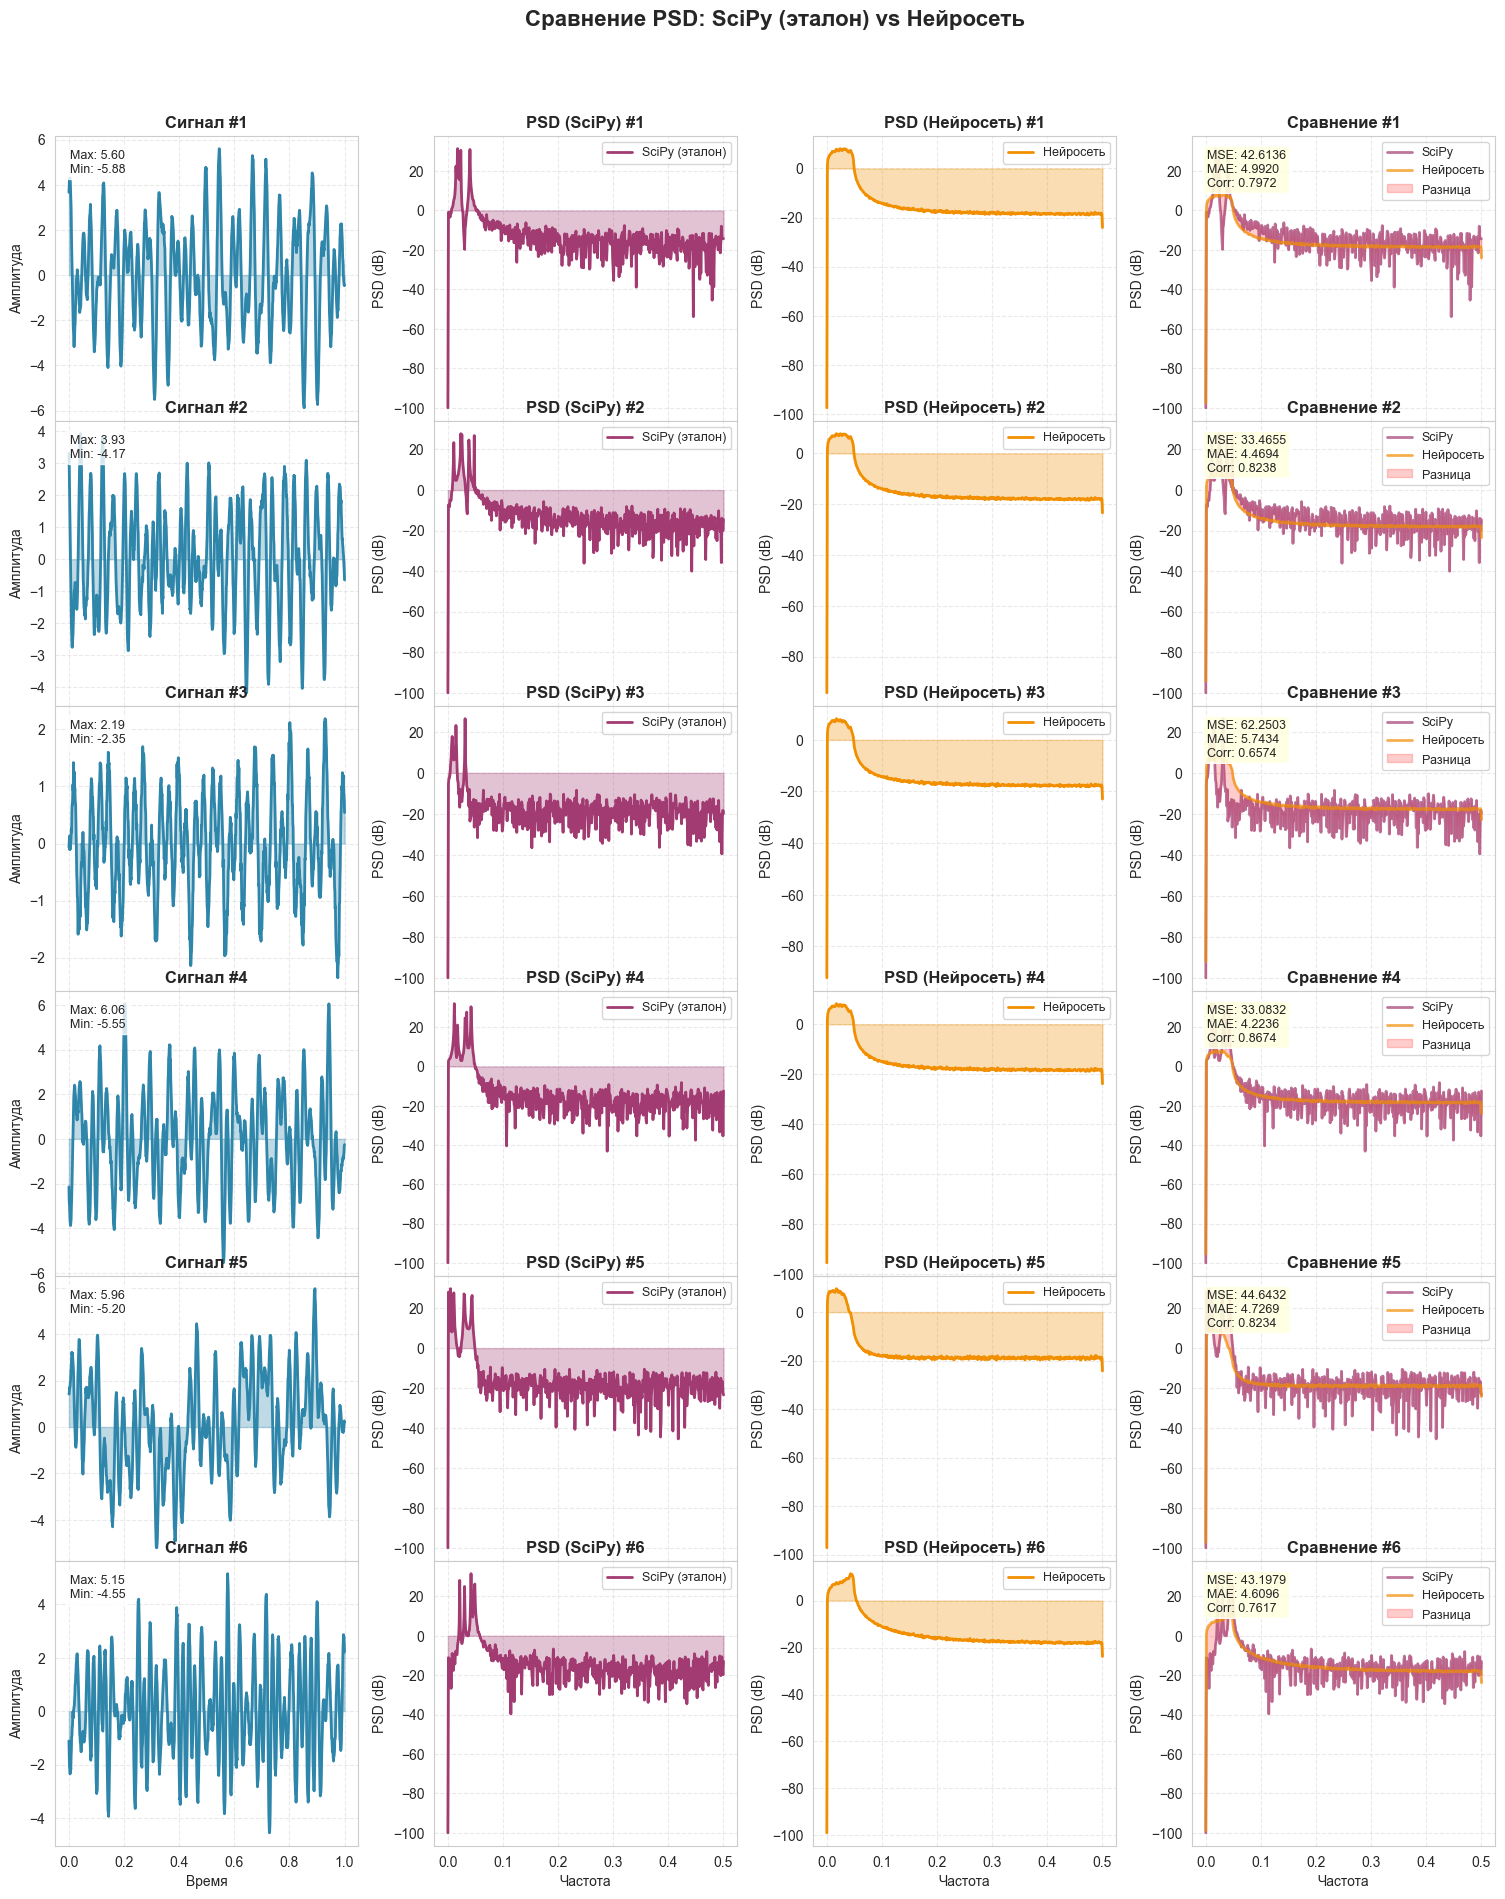

In [201]:
# Генерируем тестовые сигналы для валидации PSD
n_test_psd = min(6, 6)  # ограничим 6 примерами
test_signals_psd = np.array([GenerateSignal() for _ in range(n_test_psd)])

psd_model.eval()
with torch.no_grad():
  test_tensor_psd = torch.FloatTensor(test_signals_psd).to(CONSTS["device"])
  psd_predictions = psd_model(test_tensor_psd).cpu().numpy()

psd_scipy = []
freqs_list = []

for sig in test_signals_psd:
  freqs, psd = signal.periodogram(sig, fs=1.0, scaling="density")
  psd_db = 10 * np.log10(psd + 1e-10)
  psd_scipy.append(psd_db)
  freqs_list.append(freqs)

psd_scipy = np.array(psd_scipy)

fig = plt.figure(figsize=(16, 3 * n_test_psd))
fig.suptitle(
  "Сравнение PSD: SciPy (эталон) vs Нейросеть", fontsize=16, fontweight="bold", y=1.02
)

for i in range(n_test_psd):
  gs = GridSpec(
    1,
    4,
    figure=fig,
    left=0.05,
    right=0.95,
    top=0.95 - i * 0.95 / n_test_psd,
    bottom=0.95 - (i + 1) * 0.95 / n_test_psd,
    wspace=0.25,
  )

  # 1. Исходный сигнал
  ax0 = fig.add_subplot(gs[0, 0])
  time = np.linspace(0, 1, len(test_signals_psd[i]))
  ax0.plot(time, test_signals_psd[i], color="#2E86AB", linewidth=2)
  ax0.fill_between(time, test_signals_psd[i], alpha=0.3, color="#2E86AB")

  ax0.set_title(f"Сигнал #{i + 1}", fontsize=12, fontweight="bold")
  ax0.set_xlabel("Время", fontsize=10)
  ax0.set_ylabel("Амплитуда", fontsize=10)
  ax0.grid(True, alpha=0.4, linestyle="--")

  stats_text = (
    f"Max: {test_signals_psd[i].max():.2f}\nMin: {test_signals_psd[i].min():.2f}"
  )
  ax0.text(
    0.05,
    0.95,
    stats_text,
    transform=ax0.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
  )

  # 2. PSD от scipy (эталон)
  ax1 = fig.add_subplot(gs[0, 1])
  ax1.plot(
    freqs_list[i], psd_scipy[i], color="#A23B72", linewidth=2, label="SciPy (эталон)"
  )
  ax1.fill_between(freqs_list[i], psd_scipy[i], alpha=0.3, color="#A23B72")

  ax1.set_title(f"PSD (SciPy) #{i + 1}", fontsize=12, fontweight="bold")
  ax1.set_xlabel("Частота", fontsize=10)
  ax1.set_ylabel("PSD (dB)", fontsize=10)
  ax1.grid(True, alpha=0.4, linestyle="--")
  ax1.legend(loc="upper right", fontsize=9)

  # 3. PSD от нейросети
  ax2 = fig.add_subplot(gs[0, 2])
  ax2.plot(
    freqs_list[i], psd_predictions[i], color="#F18F01", linewidth=2, label="Нейросеть"
  )
  ax2.fill_between(freqs_list[i], psd_predictions[i], alpha=0.3, color="#F18F01")

  ax2.set_title(f"PSD (Нейросеть) #{i + 1}", fontsize=12, fontweight="bold")
  ax2.set_xlabel("Частота", fontsize=10)
  ax2.set_ylabel("PSD (dB)", fontsize=10)
  ax2.grid(True, alpha=0.4, linestyle="--")
  ax2.legend(loc="upper right", fontsize=9)

  # 4. Сравнение обоих PSD
  ax3 = fig.add_subplot(gs[0, 3])
  ax3.plot(
    freqs_list[i], psd_scipy[i], color="#A23B72", linewidth=2, alpha=0.7, label="SciPy"
  )
  ax3.plot(
    freqs_list[i],
    psd_predictions[i],
    color="#F18F01",
    linewidth=2,
    alpha=0.7,
    label="Нейросеть",
  )

  ax3.fill_between(
    freqs_list[i],
    psd_scipy[i],
    psd_predictions[i],
    alpha=0.2,
    color="red",
    label="Разница",
  )

  ax3.set_title(f"Сравнение #{i + 1}", fontsize=12, fontweight="bold")
  ax3.set_xlabel("Частота", fontsize=10)
  ax3.set_ylabel("PSD (dB)", fontsize=10)
  ax3.grid(True, alpha=0.4, linestyle="--")
  ax3.legend(loc="upper right", fontsize=9)

  mse = np.mean((psd_scipy[i] - psd_predictions[i]) ** 2)
  mae = np.mean(np.abs(psd_scipy[i] - psd_predictions[i]))
  correlation = np.corrcoef(psd_scipy[i], psd_predictions[i])[0, 1]

  metrics_text = f"MSE: {mse:.4f}\nMAE: {mae:.4f}\nCorr: {correlation:.4f}"
  ax3.text(
    0.05,
    0.95,
    metrics_text,
    transform=ax3.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9),
  )

plt.tight_layout()
plt.show()


In [ ]:
print("\n" + "=" * 70)
print("Валидация PSD: SciPy vs Нейросеть")
print("=" * 70)

mse_list = []
mae_list = []
corr_list = []

for i in range(n_test_psd):
  # MSE
  mse = np.mean((psd_scipy[i] - psd_predictions[i]) ** 2)
  mse_list.append(mse)

  # MAE (Mean Absolute Error)
  mae = np.mean(np.abs(psd_scipy[i] - psd_predictions[i]))
  mae_list.append(mae)

  # Корреляция
  correlation = np.corrcoef(psd_scipy[i], psd_predictions[i])[0, 1]
  corr_list.append(correlation)

print(f"{'Сигнал':<15} {'MSE':<15} {'MAE':<15} {'Корреляция':<15}")
print("-" * 70)

for i in range(n_test_psd):
  print(
    f"{f'#{i + 1}':<15} {mse_list[i]:<15.4f} {mae_list[i]:<15.4f} {corr_list[i]:<15.6f}"
  )

print("-" * 70)
print(
  f"{'Среднее:':<15} {np.mean(mse_list):<15.4f} {np.mean(mae_list):<15.4f} {np.mean(corr_list):<15.6f}"
)
print("=" * 70)

# Оценка качества
avg_corr = np.mean(corr_list)
if avg_corr > 0.95:
  quality = " ОТЛИЧНОЕ"
  quality_desc = "Форма спектра воспроизведена почти идеально"
elif avg_corr > 0.85:
  quality = " ХОРОШЕЕ"
  quality_desc = "Форма спектра воспроизведена хорошо"
elif avg_corr > 0.75:
  quality = " ПРИЕМЛЕМОЕ"
  quality_desc = "Основные черты спектра уловлены"
elif avg_corr > 0.60:
  quality = " УДОВЛЕТВОРИТЕЛЬНОЕ"
  quality_desc = "Сходство есть, но есть и расхождения"
else:
  quality = " НЕДОСТАТОЧНОЕ"
  quality_desc = "Требуется дообучение модели"

print("\nОЦЕНКА КАЧЕСТВА ВОСПРОИЗВЕДЕНИЯ ФОРМЫ СПЕКТРА:")
print(f"  {quality}")
print(f"  {quality_desc}")
print(f"  Средняя корреляция: {avg_corr:.4f}")
print("=" * 70)


Валидация PSD: SciPy vs Нейросеть
Сигнал          MSE             MAE             Корреляция     
----------------------------------------------------------------------
#1              42.6136         4.9920          0.797220       
#2              33.4655         4.4694          0.823807       
#3              62.2503         5.7434          0.657383       
#4              33.0832         4.2236          0.867375       
#5              44.6432         4.7269          0.823421       
#6              43.1979         4.6096          0.761728       
----------------------------------------------------------------------
Среднее:        43.2090         4.7942          0.788489       

ОЦЕНКА КАЧЕСТВА ВОСПРОИЗВЕДЕНИЯ ФОРМЫ СПЕКТРА:
   ПРИЕМЛЕМОЕ
  Основные черты спектра уловлены
  Средняя корреляция: 0.7885
